# Flower Classification with a Pretrained Vision Transformer

This notebook solves the same 5-class flower classification task with a **pretrained Vision Transformer (ViT)** instead of MobileNetV2.

The workflow mirrors the transfer-learning notebook:

1. Load the flower dataset from the local folder structure.
2. Train a **feature extractor** by freezing the pretrained ViT backbone.
3. **Fine tune** the top transformer blocks with a smaller learning rate.
4. Evaluate both stages with validation loss, validation accuracy, a confusion matrix, per-class accuracy, and prediction previews.
5. Predict the unlabeled test images and export a submission CSV.

Pretrained checkpoint used: `google/vit-base-patch16-224`


In [1]:
import csv
import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import transformers

from tensorflow import keras
from transformers import AutoImageProcessor, TFViTForImageClassification

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

tf.random.set_seed(42)
np.random.seed(42)

MODEL_CHECKPOINT = "google/vit-base-patch16-224"
VAL_SPLIT = 0.20
SEED = 42
BATCH_SIZE = 8
FEATURE_EPOCHS = 4
FINE_TUNE_EPOCHS = 3
FINE_TUNE_BLOCKS = 3
AUTOTUNE = tf.data.AUTOTUNE

candidate_data_dirs = [
    Path(r"F:\ML\CV_Project2_Codebase\5-flowers-image-classification"),
    Path("5-flowers-image-classification"),
]
DATA_DIR = next((path for path in candidate_data_dirs if path.exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate the flower dataset. Update candidate_data_dirs if the dataset lives somewhere else."
    )

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

FEATURE_MODEL_DIR = DATA_DIR / "vit_feature_extractor_best"
FINE_TUNED_MODEL_DIR = DATA_DIR / "vit_fine_tuned_best"
FINAL_MODEL_DIR = DATA_DIR / "vit_final_flower_classifier"
SUBMISSION_PATH = DATA_DIR / "submission_vit_flower_classifier.csv"

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError("Expected both train and test folders inside the dataset directory.")

print("TensorFlow version:", tf.__version__)
print("Transformers version:", transformers.__version__)
print("Dataset directory:", DATA_DIR.resolve())
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))


f:\ML\CV_Project2_Codebase\env311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



TensorFlow version: 2.21.0
Transformers version: 4.49.0
Dataset directory: F:\ML\CV_Project2_Codebase\5-flowers-image-classification
Visible GPUs: []


In [2]:
processor = AutoImageProcessor.from_pretrained(MODEL_CHECKPOINT)
IMG_HEIGHT = processor.size["height"]
IMG_WIDTH = processor.size["width"]

IMAGE_MEAN = tf.constant(processor.image_mean, dtype=tf.float32)
IMAGE_STD = tf.constant(processor.image_std, dtype=tf.float32)

class_names = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])
num_classes = len(class_names)
label2id = {name: idx for idx, name in enumerate(class_names)}
id2label = {idx: name for name, idx in label2id.items()}

def list_image_files(folder):
    return sorted(
        [
            path
            for path in folder.iterdir()
            if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
    )

train_counts = {name: len(list_image_files(TRAIN_DIR / name)) for name in class_names}
test_paths = sorted(
    list_image_files(TEST_DIR),
    key=lambda path: int(path.stem) if path.stem.isdigit() else path.stem,
)
test_ids = [int(path.stem) if path.stem.isdigit() else path.stem for path in test_paths]

print("Images per class:")
for name in class_names:
    print(f"  {name:<10} -> {train_counts[name]}")

print("\nLabel mapping:")
for name, idx in label2id.items():
    print(f"  {idx}: {name}")

print("\nViT image size:", (IMG_HEIGHT, IMG_WIDTH))
print("Normalization mean:", processor.image_mean)
print("Normalization std:", processor.image_std)
print(f"Number of classes: {num_classes}")
print(f"Total training images: {sum(train_counts.values())}")
print(f"Test images: {len(test_paths)}")


Images per class:
  daisy      -> 691
  dandelion  -> 951
  rose       -> 694
  sunflower  -> 659
  tulip      -> 870

Label mapping:
  0: daisy
  1: dandelion
  2: rose
  3: sunflower
  4: tulip

ViT image size: (224, 224)
Normalization mean: [0.5, 0.5, 0.5]
Normalization std: [0.5, 0.5, 0.5]
Number of classes: 5
Total training images: 3865
Test images: 400


In [3]:
def make_stratified_split(train_dir, label2id, val_split, seed):
    rng = np.random.default_rng(seed)
    train_paths = []
    train_labels = []
    val_paths = []
    val_labels = []

    for class_name in class_names:
        class_paths = np.array(list_image_files(TRAIN_DIR / class_name), dtype=object)
        class_paths = rng.permutation(class_paths)

        if len(class_paths) < 2:
            raise ValueError(
                f"Need at least 2 images in class {class_name!r} for a train/validation split."
            )

        val_count = max(1, int(np.round(len(class_paths) * val_split)))
        val_count = min(len(class_paths) - 1, val_count)

        label = label2id[class_name]
        val_class_paths = class_paths[:val_count]
        train_class_paths = class_paths[val_count:]

        train_paths.extend(str(path) for path in train_class_paths)
        train_labels.extend([label] * len(train_class_paths))
        val_paths.extend(str(path) for path in val_class_paths)
        val_labels.extend([label] * len(val_class_paths))

    train_paths = np.array(train_paths)
    train_labels = np.array(train_labels, dtype=np.int32)
    val_paths = np.array(val_paths)
    val_labels = np.array(val_labels, dtype=np.int32)

    train_order = rng.permutation(len(train_paths))
    val_order = rng.permutation(len(val_paths))

    return (
        train_paths[train_order],
        train_labels[train_order],
        val_paths[val_order],
        val_labels[val_order],
    )


def load_raw_labeled_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(tf.cast(image, tf.float32), (IMG_HEIGHT, IMG_WIDTH))
    return image, label


def build_raw_labeled_dataset(paths, labels, batch_size, shuffle):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_raw_labeled_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)

    return dataset.batch(batch_size).prefetch(AUTOTUNE)


train_paths, train_labels, val_paths, val_labels = make_stratified_split(
    TRAIN_DIR,
    label2id,
    VAL_SPLIT,
    SEED,
)

train_split_counts = {
    name: int(np.sum(train_labels == label2id[name])) for name in class_names
}
val_split_counts = {
    name: int(np.sum(val_labels == label2id[name])) for name in class_names
}

missing_val_classes = [name for name in class_names if val_split_counts[name] == 0]
if missing_val_classes:
    raise ValueError(f"Missing classes in val_ds: {missing_val_classes}")

print("Stratified split counts:")
for name in class_names:
    print(
        f"  {name:<10} -> train={train_split_counts[name]:>4}, val={val_split_counts[name]:>3}"
    )

print(f"\nTotal train images: {len(train_paths)}")
print(f"Total validation images: {len(val_paths)}")

raw_train_ds = build_raw_labeled_dataset(
    train_paths,
    train_labels,
    BATCH_SIZE,
    shuffle=True,
)
raw_val_ds = build_raw_labeled_dataset(
    val_paths,
    val_labels,
    BATCH_SIZE,
    shuffle=False,
)

sample_images, sample_labels = next(iter(raw_train_ds.take(1)))
print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("First 10 labels:", sample_labels[:10].numpy())


Stratified split counts:
  daisy      -> train= 553, val=138
  dandelion  -> train= 761, val=190
  rose       -> train= 555, val=139
  sunflower  -> train= 527, val=132
  tulip      -> train= 696, val=174

Total train images: 3092
Total validation images: 773
Image batch shape: (8, 224, 224, 3)
Label batch shape: (8,)
First 10 labels: [3 4 3 4 3 4 4 1]


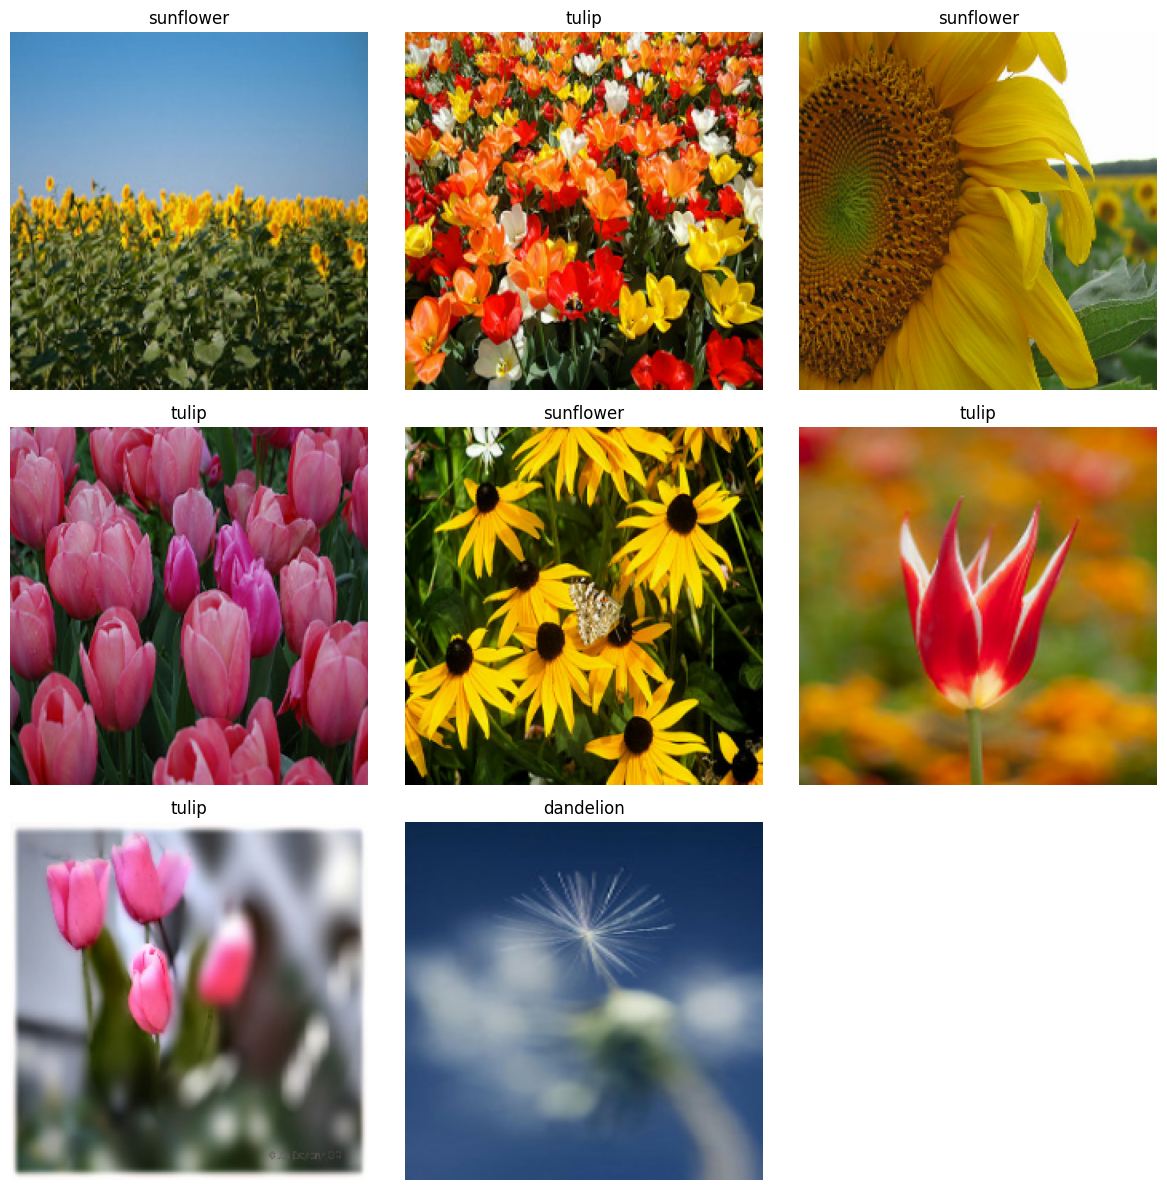

In [4]:
num_preview_images = min(9, int(sample_images.shape[0]))

plt.figure(figsize=(12, 12))
for i in range(num_preview_images):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title(class_names[int(sample_labels[i].numpy())])
    plt.axis("off")
plt.tight_layout()


In [5]:
@tf.autograph.experimental.do_not_convert
def prepare_images(images):
    # Hugging Face ViT expects normalized channel-first tensors: (batch, channels, height, width).
    images = tf.cast(images, tf.float32) / 255.0
    images = (images - IMAGE_MEAN) / IMAGE_STD
    images = tf.transpose(images, perm=[0, 3, 1, 2])
    return images

@tf.autograph.experimental.do_not_convert
def preprocess_labeled_batch(images, labels):
    return {"pixel_values": prepare_images(images)}, labels

@tf.autograph.experimental.do_not_convert
def preprocess_unlabeled_batch(images):
    return {"pixel_values": prepare_images(images)}

def build_processed_datasets():
    train_dataset = raw_train_ds.map(
        preprocess_labeled_batch,
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)

    val_dataset = raw_val_ds.map(
        preprocess_labeled_batch,
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)

    return train_dataset, val_dataset

train_ds, val_ds = build_processed_datasets()

def build_vit_model():
    return TFViTForImageClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

def reset_directory(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def count_trainable_parameters(model):
    return int(
        np.sum(
            [
                np.prod(variable.shape.as_list())
                for variable in model.trainable_variables
            ]
        )
    )

def describe_trainable_state(model, title):
    print(title)
    print("  Total parameters:    ", f"{model.count_params():,}")
    print("  Trainable parameters:", f"{count_trainable_parameters(model):,}")
    print("  Frozen parameters:   ", f"{model.count_params() - count_trainable_parameters(model):,}")

def compile_for_training(model, learning_rate, weight_decay=1e-4):
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=weight_decay,
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )

def freeze_backbone(model):
    model.vit.trainable = False
    model.classifier.trainable = True

def enable_partial_fine_tuning(model, num_blocks):
    model.vit.trainable = True

    if hasattr(model.vit, "embeddings"):
        model.vit.embeddings.trainable = False

    for block in model.vit.encoder.layer[:-num_blocks]:
        block.trainable = False

    for block in model.vit.encoder.layer[-num_blocks:]:
        block.trainable = True

    if hasattr(model.vit, "layernorm"):
        model.vit.layernorm.trainable = True

    model.classifier.trainable = True

def get_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=1,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

def merge_histories(histories):
    merged = {}
    for history in histories:
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

def plot_history(histories, fine_tune_start=None):
    history_dict = merge_histories(histories)
    epochs = range(1, len(history_dict["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history_dict["loss"], marker="o", label="train")
    axes[0].plot(epochs, history_dict["val_loss"], marker="o", label="validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history_dict["accuracy"], marker="o", label="train")
    axes[1].plot(epochs, history_dict["val_accuracy"], marker="o", label="validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    if fine_tune_start is not None:
        for axis in axes:
            axis.axvline(fine_tune_start + 0.5, color="black", linestyle="--", alpha=0.7)

    plt.tight_layout()
    return history_dict

def collect_logits_and_labels(model, dataset):
    logits_batches = []
    label_batches = []

    for batch_inputs, batch_labels in dataset:
        outputs = model(batch_inputs, training=False)
        logits_batches.append(outputs.logits.numpy())
        label_batches.append(batch_labels.numpy())

    logits = np.concatenate(logits_batches, axis=0)
    labels = np.concatenate(label_batches, axis=0)
    return logits, labels

def collect_logits(model, dataset):
    logits_batches = []

    for batch_inputs in dataset:
        outputs = model(batch_inputs, training=False)
        logits_batches.append(outputs.logits.numpy())

    return np.concatenate(logits_batches, axis=0)

def evaluate_model(model, dataset, title):
    logits, y_true = collect_logits_and_labels(model, dataset)
    y_pred = np.argmax(logits, axis=1)

    loss = tf.keras.losses.sparse_categorical_crossentropy(
        y_true,
        logits,
        from_logits=True,
    ).numpy().mean()
    accuracy = np.mean(y_pred == y_true)

    confusion = tf.math.confusion_matrix(
        y_true,
        y_pred,
        num_classes=num_classes,
    ).numpy()

    per_class_totals = confusion.sum(axis=1)
    per_class_correct = np.diag(confusion)
    per_class_accuracy = np.divide(
        per_class_correct,
        per_class_totals,
        out=np.zeros(num_classes, dtype=np.float64),
        where=per_class_totals > 0,
    )

    correct = int(np.sum(y_pred == y_true))
    incorrect = int(np.sum(y_pred != y_true))
    total = int(len(y_true))

    print(f"{title} loss: {loss:.4f}")
    print(f"{title} accuracy: {accuracy:.4f}")
    print(f"{title} validation images : {total}")
    print(f"{title} correct predictions: {correct}")
    print(f"{title} mispredictions     : {incorrect}")

    plt.figure(figsize=(8, 6))
    plt.imshow(confusion, interpolation="nearest", cmap="Blues")
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    threshold = confusion.max() / 2 if confusion.max() else 0
    for i in range(confusion.shape[0]):
        for j in range(confusion.shape[1]):
            plt.text(
                j,
                i,
                str(confusion[i, j]),
                ha="center",
                va="center",
                color="white" if confusion[i, j] > threshold else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    print("\nPer-class validation accuracy:")
    for class_name, class_correct, class_total, class_accuracy in zip(
        class_names,
        per_class_correct,
        per_class_totals,
        per_class_accuracy,
    ):
        print(
            f"  {class_name:<10} -> {class_correct:>3}/{class_total:<3} = {class_accuracy:.4f}"
        )

    return {
        "loss": float(loss),
        "accuracy": float(accuracy),
        "per_class_accuracy": per_class_accuracy.tolist(),
    }

def preview_validation_predictions(model, raw_dataset, rows=2, cols=4):
    images, labels = next(iter(raw_dataset.take(1)))
    logits = model({"pixel_values": prepare_images(images)}, training=False).logits.numpy()
    predictions = np.argmax(logits, axis=1)
    probabilities = tf.nn.softmax(logits, axis=-1).numpy()
    confidences = np.max(probabilities, axis=1)

    num_images = min(rows * cols, len(predictions))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)
        image = np.clip(images[i].numpy(), 0, 255).astype("uint8")
        true_idx = int(labels[i].numpy())
        pred_idx = int(predictions[i])
        is_correct = true_idx == pred_idx

        plt.imshow(image)
        plt.title(
            f"true: {class_names[true_idx]}\npred: {class_names[pred_idx]} ({confidences[i]:.2f})",
            color="green" if is_correct else "red",
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def build_raw_test_dataset(paths):
    def load_image(path):
        image_bytes = tf.io.read_file(path)
        image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])
        image = tf.image.resize(tf.cast(image, tf.float32), (IMG_HEIGHT, IMG_WIDTH))
        return image

    dataset = tf.data.Dataset.from_tensor_slices([str(path) for path in paths])
    return dataset.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

raw_test_ds = build_raw_test_dataset(test_paths)
test_ds = raw_test_ds.map(preprocess_unlabeled_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

def preview_test_predictions(model, raw_dataset, ids, rows=2, cols=4):
    images = next(iter(raw_dataset.take(1)))
    logits = model({"pixel_values": prepare_images(images)}, training=False).logits.numpy()
    predictions = np.argmax(logits, axis=1)
    probabilities = tf.nn.softmax(logits, axis=-1).numpy()
    confidences = np.max(probabilities, axis=1)

    num_images = min(rows * cols, len(predictions))
    first_batch_ids = ids[: len(predictions)]

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(np.clip(images[i].numpy(), 0, 255).astype("uint8"))
        plt.title(
            f"id={first_batch_ids[i]}\n{class_names[int(predictions[i])]} ({confidences[i]:.2f})"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


## Step 1: Train a Frozen ViT Feature Extractor

In the first stage, we keep the pretrained ViT backbone frozen and train only the classifier head. This gives us a clean baseline for the pretrained transformer features on the flower dataset.


In [6]:
feature_extractor_model = build_vit_model()
freeze_backbone(feature_extractor_model)
compile_for_training(feature_extractor_model, learning_rate=1e-3, weight_decay=1e-4)
describe_trainable_state(feature_extractor_model, "Frozen ViT feature extractor:")

feature_history = feature_extractor_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FEATURE_EPOCHS,
    callbacks=get_callbacks(),
)

reset_directory(FEATURE_MODEL_DIR)
feature_extractor_model.save_pretrained(str(FEATURE_MODEL_DIR))
processor.save_pretrained(str(FEATURE_MODEL_DIR))

best_feature_model = TFViTForImageClassification.from_pretrained(str(FEATURE_MODEL_DIR))


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTForImageClassification: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFViTForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTForImageClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFViTForImageClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTForImageClassification for predictions without further training.
Some weights of TFViTForImageClassification were not initialized from the model checkpoint are newly initialize

Frozen ViT feature extractor:
  Total parameters:     85,802,501
  Trainable parameters: 3,845
  Frozen parameters:    85,798,656
Epoch 1/4


387/387 [==============================] - 440s 1s/step - loss: 0.1679 - accuracy: 0.9531 - val_loss: 0.1102 - val_accuracy: 0.9702 - lr: 0.0010
Epoch 2/4
387/387 [==============================] - ETA: 0s - loss: 0.0637 - accuracy: 0.9832
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
387/387 [==============================] - 413s 1s/step - loss: 0.0637 - accuracy: 0.9832 - val_loss: 0.1104 - val_accuracy: 0.9677 - lr: 0.0010
Epoch 3/4
387/387 [==============================] - 424s 1s/step - loss: 0.0335 - accuracy: 0.9935 - val_loss: 0.1070 - val_accuracy: 0.9715 - lr: 2.0000e-04
Epoch 4/4
387/387 [==============================] - 422s 1s/step - loss: 0.0303 - accuracy: 0.9942 - val_loss: 0.1058 - val_accuracy: 0.9690 - lr: 2.0000e-04


All model checkpoint layers were used when initializing TFViTForImageClassification.

All the layers of TFViTForImageClassification were initialized from the model checkpoint at F:\ML\CV_Project2_Codebase\5-flowers-image-classification\vit_feature_extractor_best.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTForImageClassification for predictions without further training.


Frozen ViT Feature Extractor loss: 0.1058
Frozen ViT Feature Extractor accuracy: 0.9690
Frozen ViT Feature Extractor validation images : 773
Frozen ViT Feature Extractor correct predictions: 749
Frozen ViT Feature Extractor mispredictions     : 24


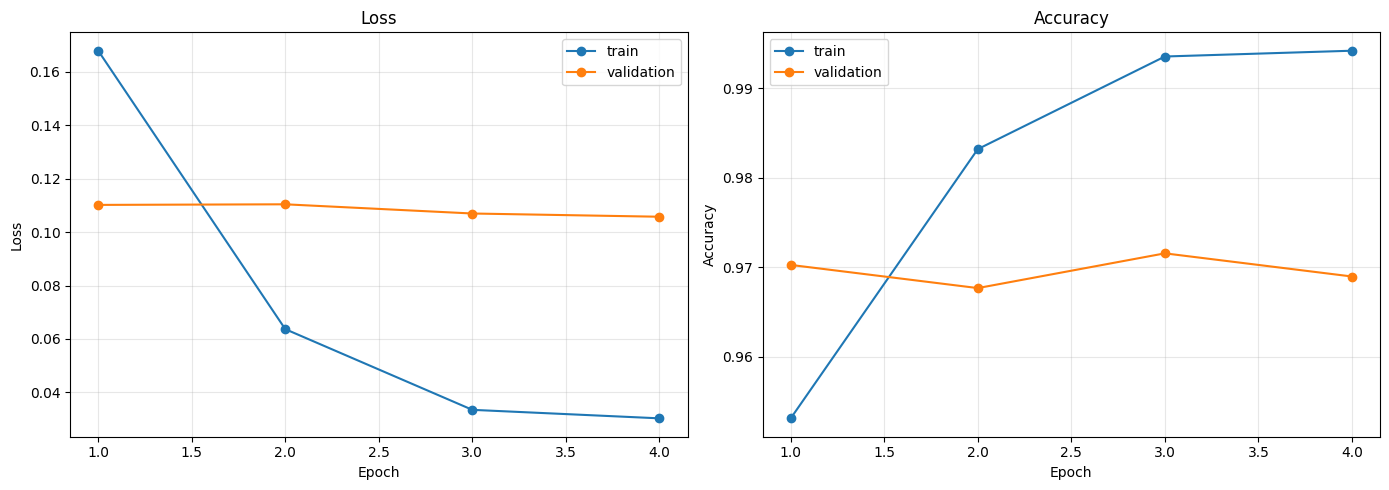

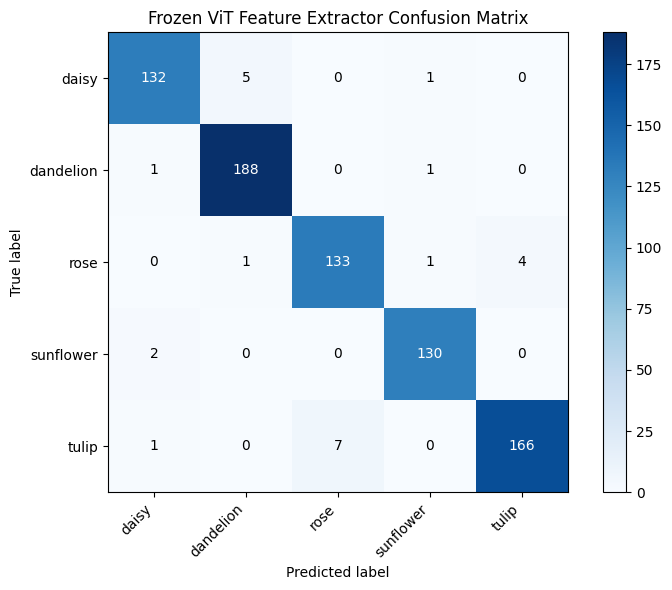


Per-class validation accuracy:
  daisy      -> 132/138 = 0.9565
  dandelion  -> 188/190 = 0.9895
  rose       -> 133/139 = 0.9568
  sunflower  -> 130/132 = 0.9848
  tulip      -> 166/174 = 0.9540


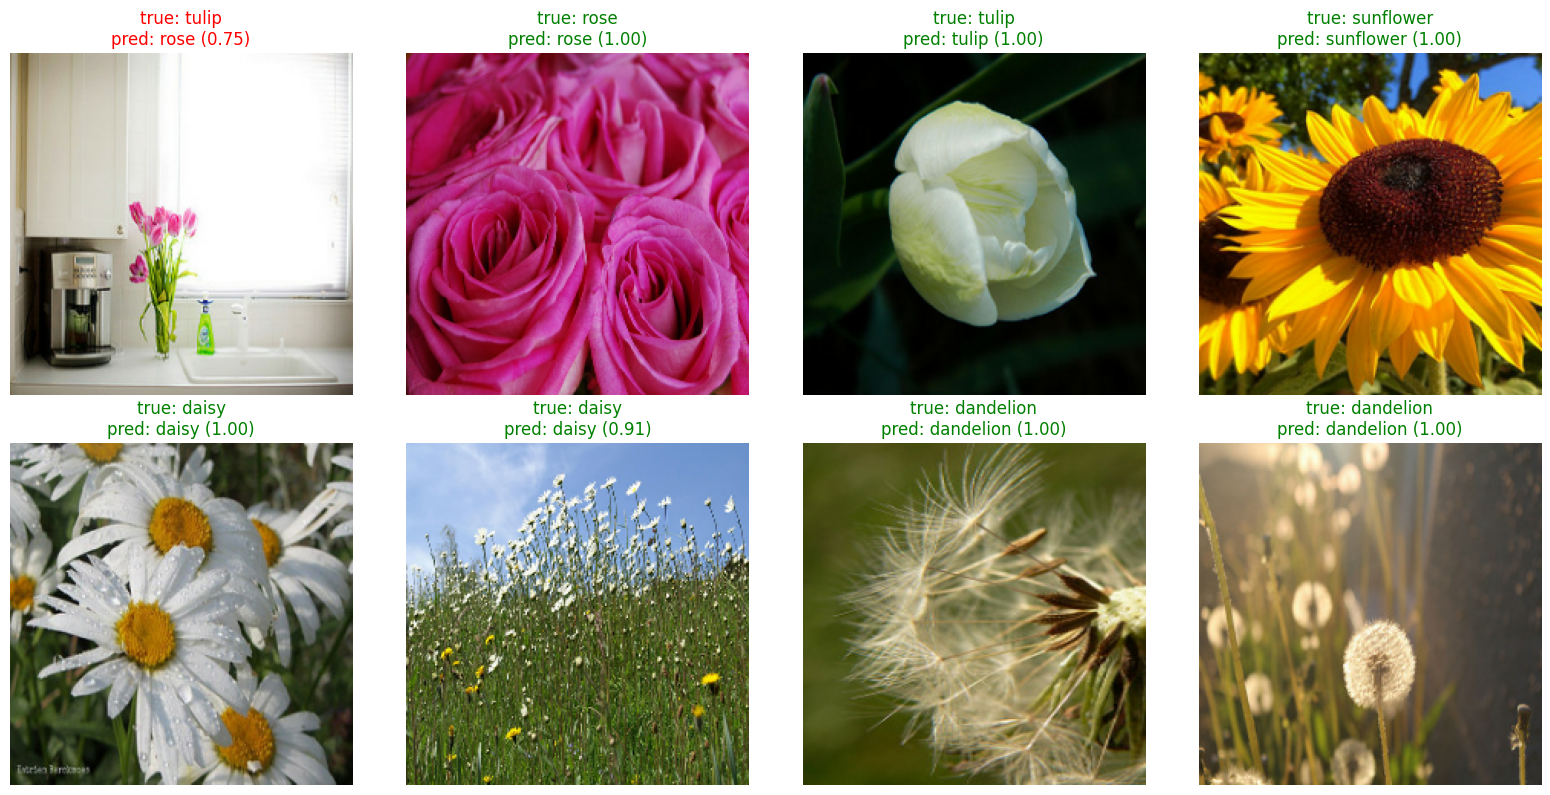

In [7]:
plot_history([feature_history])
feature_metrics = evaluate_model(best_feature_model, val_ds, "Frozen ViT Feature Extractor")
preview_validation_predictions(best_feature_model, raw_val_ds)


## Step 2: Fine Tune the Top Transformer Blocks

Next, we unfreeze the top ViT encoder blocks and continue training with a smaller learning rate. This lets the pretrained transformer adapt more specifically to flower classification while keeping most of the backbone stable.


In [8]:
enable_partial_fine_tuning(feature_extractor_model, num_blocks=FINE_TUNE_BLOCKS)
compile_for_training(feature_extractor_model, learning_rate=5e-5, weight_decay=1e-5)
describe_trainable_state(
    feature_extractor_model,
    f"Partially fine-tuned ViT (last {FINE_TUNE_BLOCKS} blocks trainable):",
)

fine_tune_start_epoch = len(feature_history.history["loss"])
total_epochs = fine_tune_start_epoch + FINE_TUNE_EPOCHS

fine_tune_history = feature_extractor_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=fine_tune_start_epoch,
    callbacks=get_callbacks(),
)

reset_directory(FINE_TUNED_MODEL_DIR)
feature_extractor_model.save_pretrained(str(FINE_TUNED_MODEL_DIR))
processor.save_pretrained(str(FINE_TUNED_MODEL_DIR))

best_fine_tuned_model = TFViTForImageClassification.from_pretrained(str(FINE_TUNED_MODEL_DIR))


Partially fine-tuned ViT (last 3 blocks trainable):
  Total parameters:     85,802,501
  Trainable parameters: 21,268,997
  Frozen parameters:    64,533,504
Epoch 5/7
387/387 [==============================] - 647s 2s/step - loss: 0.0372 - accuracy: 0.9903 - val_loss: 0.1256 - val_accuracy: 0.9690 - lr: 5.0000e-05
Epoch 6/7
387/387 [==============================] - 641s 2s/step - loss: 0.0044 - accuracy: 0.9994 - val_loss: 0.1135 - val_accuracy: 0.9702 - lr: 5.0000e-05
Epoch 7/7
387/387 [==============================] - 640s 2s/step - loss: 0.0032 - accuracy: 0.9994 - val_loss: 0.1131 - val_accuracy: 0.9715 - lr: 5.0000e-05


All model checkpoint layers were used when initializing TFViTForImageClassification.

All the layers of TFViTForImageClassification were initialized from the model checkpoint at F:\ML\CV_Project2_Codebase\5-flowers-image-classification\vit_fine_tuned_best.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTForImageClassification for predictions without further training.


Fine-Tuned ViT loss: 0.1131
Fine-Tuned ViT accuracy: 0.9715
Fine-Tuned ViT validation images : 773
Fine-Tuned ViT correct predictions: 751
Fine-Tuned ViT mispredictions     : 22


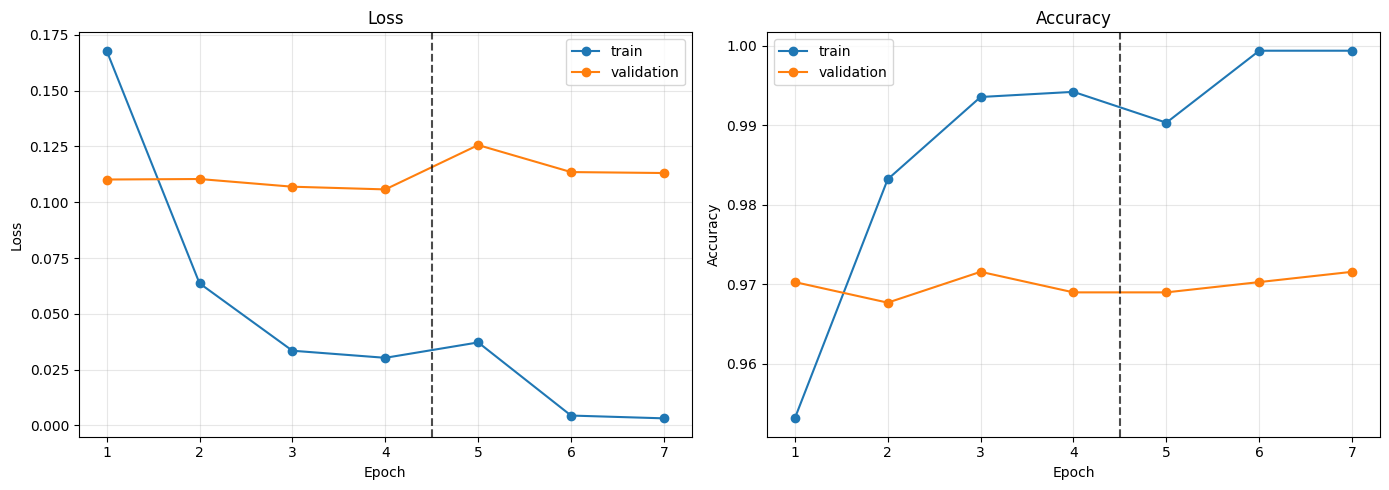

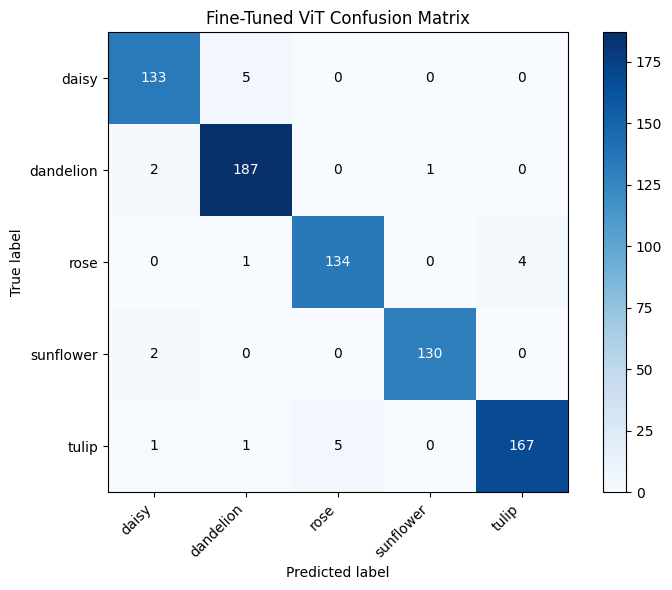


Per-class validation accuracy:
  daisy      -> 133/138 = 0.9638
  dandelion  -> 187/190 = 0.9842
  rose       -> 134/139 = 0.9640
  sunflower  -> 130/132 = 0.9848
  tulip      -> 167/174 = 0.9598

Validation comparison:
  Frozen feature extractor accuracy: 0.9690
  Fine-tuned ViT accuracy:          0.9715
  Accuracy gain:                    +0.0026

Selected final model: Fine-tuned ViT


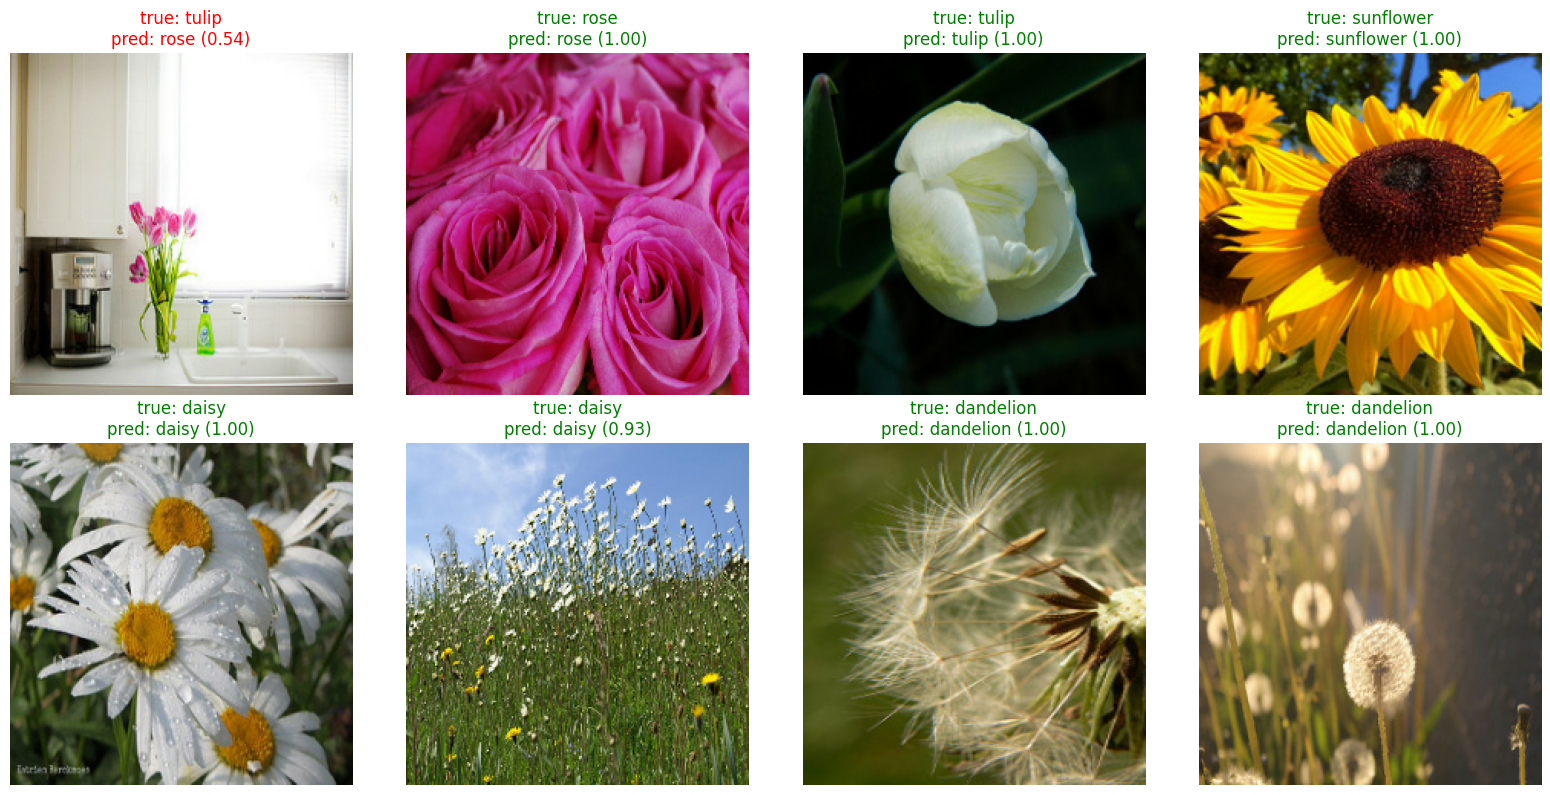

In [9]:
plot_history([feature_history, fine_tune_history], fine_tune_start=fine_tune_start_epoch)
fine_tuned_metrics = evaluate_model(best_fine_tuned_model, val_ds, "Fine-Tuned ViT")

print("\nValidation comparison:")
print(f"  Frozen feature extractor accuracy: {feature_metrics['accuracy']:.4f}")
print(f"  Fine-tuned ViT accuracy:          {fine_tuned_metrics['accuracy']:.4f}")
print(
    f"  Accuracy gain:                    "
    f"{fine_tuned_metrics['accuracy'] - feature_metrics['accuracy']:+.4f}"
)

if fine_tuned_metrics["accuracy"] >= feature_metrics["accuracy"]:
    best_model = best_fine_tuned_model
    best_model_name = "Fine-tuned ViT"
    best_model_dir = FINE_TUNED_MODEL_DIR
else:
    best_model = best_feature_model
    best_model_name = "Frozen ViT feature extractor"
    best_model_dir = FEATURE_MODEL_DIR

print(f"\nSelected final model: {best_model_name}")
preview_validation_predictions(best_model, raw_val_ds)


## Predict on the Test Set

The final stage uses whichever ViT model performed better on validation and exports a submission file with `id,label` columns for the unlabeled test images.


Preview of test predictions:
  id=1 -> sunflower (1.00)
  id=2 -> rose (1.00)
  id=3 -> tulip (1.00)
  id=4 -> dandelion (1.00)
  id=5 -> dandelion (1.00)
  id=6 -> tulip (0.96)
  id=7 -> tulip (1.00)
  id=8 -> daisy (1.00)
  id=9 -> dandelion (1.00)
  id=10 -> daisy (1.00)

Saved submission to: F:\ML\CV_Project2_Codebase\5-flowers-image-classification\submission_vit_flower_classifier.csv


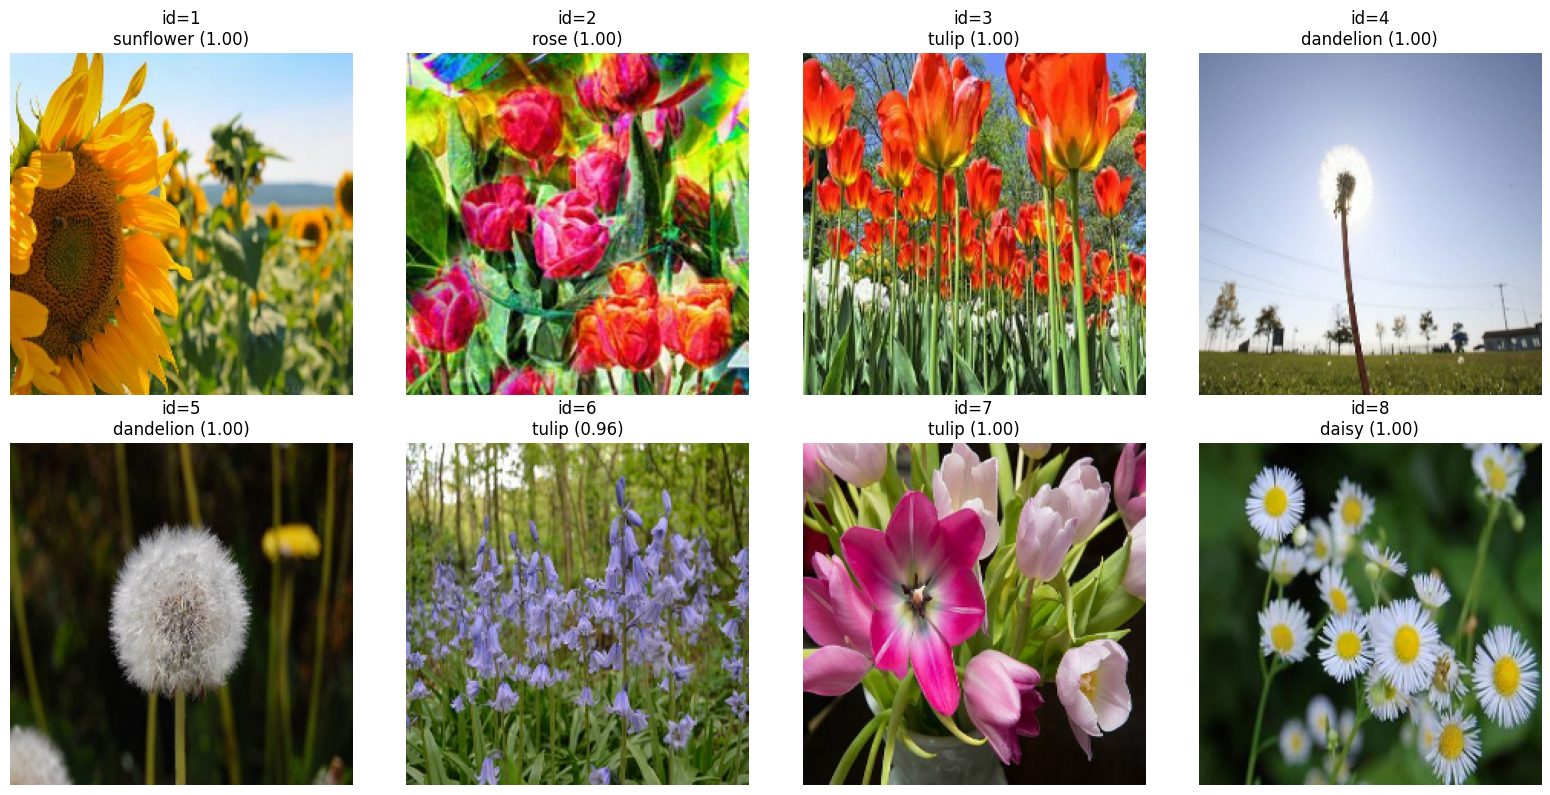

In [10]:
test_logits = collect_logits(best_model, test_ds)
test_predictions = np.argmax(test_logits, axis=1)
test_probabilities = tf.nn.softmax(test_logits, axis=-1).numpy()
test_confidences = np.max(test_probabilities, axis=1)

with SUBMISSION_PATH.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["id", "label"])
    writer.writerows(zip(test_ids, test_predictions))

print("Preview of test predictions:")
for image_id, predicted_label, confidence in list(
    zip(test_ids, test_predictions, test_confidences)
)[:10]:
    print(f"  id={image_id} -> {class_names[int(predicted_label)]} ({confidence:.2f})")

print(f"\nSaved submission to: {SUBMISSION_PATH.resolve()}")
preview_test_predictions(best_model, raw_test_ds, test_ids)


In [11]:
reset_directory(FINAL_MODEL_DIR)
best_model.save_pretrained(str(FINAL_MODEL_DIR))
processor.save_pretrained(str(FINAL_MODEL_DIR))

print("Final model source:", best_model_name)
print("Validation-selected checkpoint:", best_model_dir.resolve())
print(f"Saved final model to: {FINAL_MODEL_DIR.resolve()}")


Final model source: Fine-tuned ViT
Validation-selected checkpoint: F:\ML\CV_Project2_Codebase\5-flowers-image-classification\vit_fine_tuned_best
Saved final model to: F:\ML\CV_Project2_Codebase\5-flowers-image-classification\vit_final_flower_classifier
